In [1]:
# 1. 引入必要库
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['STHeiti']
plt.rcParams['axes.unicode_minus'] = False  # 负号用英文字体

# 2. 导入数据
df = pd.read_csv('../../data/weather.csv')
df.head()


,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [2]:
# 数据清洗
df.isna().sum() # 无无效数据
df.count()      # 共 1461 条数据

# 数据预处理
# 时间数据处理
df['date'] = pd.to_datetime(df['date'])
# df.info()   # date: datetime64[us]

# * 可分类分类
df['weather'].value_counts()    # rain sun fog drizzle snow 适合分类
df['weather'] = df['weather'].astype('category')
df.info()       # weather: category

<class 'pandas.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1461 non-null   datetime64[us]
 1   precipitation  1461 non-null   float64       
 2   temp_max       1461 non-null   float64       
 3   temp_min       1461 non-null   float64       
 4   wind           1461 non-null   float64       
 5   weather        1461 non-null   category      
dtypes: category(1), datetime64[us](1), float64(4)
memory usage: 58.7 KB


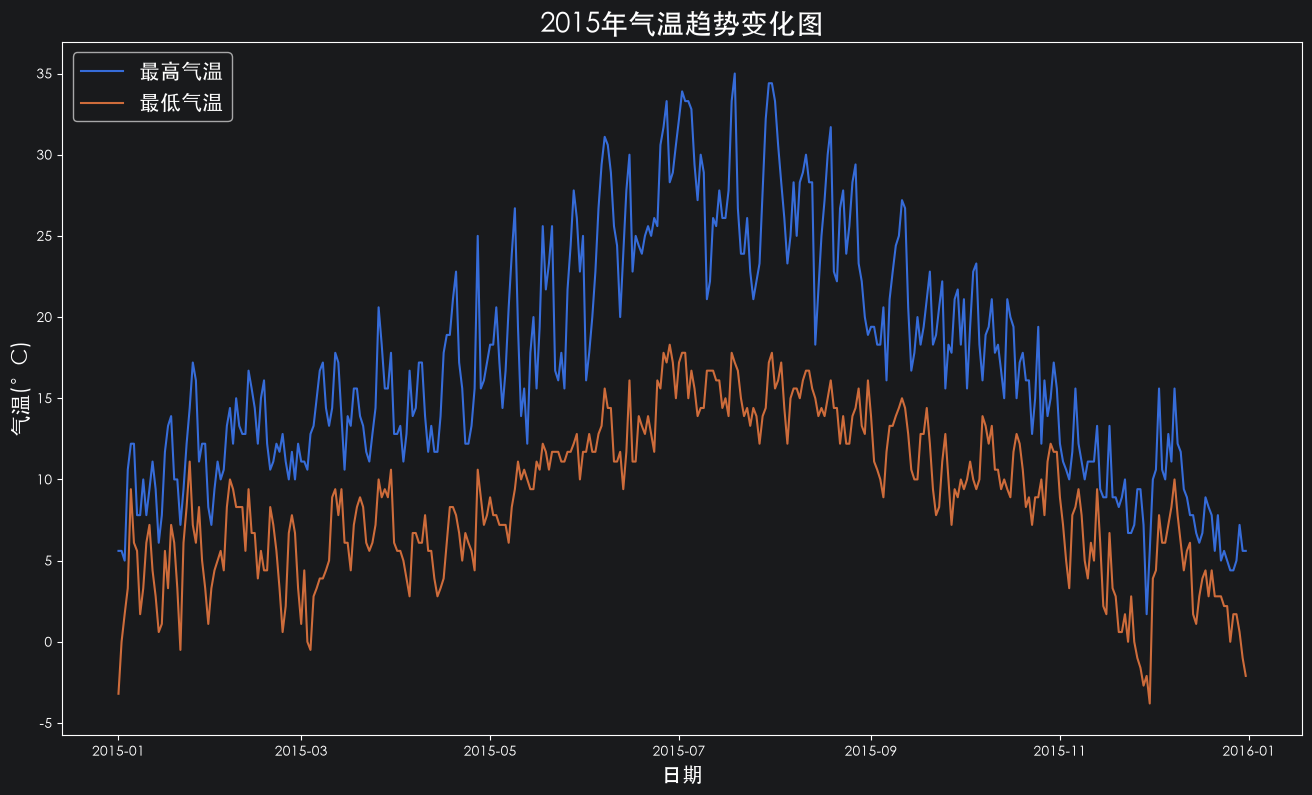

In [3]:
# 数据太多了，裁剪一下
df15 = df[df['date'].dt.year == 2015]
# 开始画图

plt.figure(figsize=(16,9))
plt.plot(df15['date'], df15['temp_max'], label='最高气温')
plt.plot(df15['date'], df15['temp_min'], label='最低气温')
plt.title('2015年气温趋势变化图', fontsize=20)
plt.legend(loc='upper left',fontsize=15)
plt.xlabel('日期', fontsize=15)
plt.ylabel('气温(°C)', fontsize=15)

plt.show()


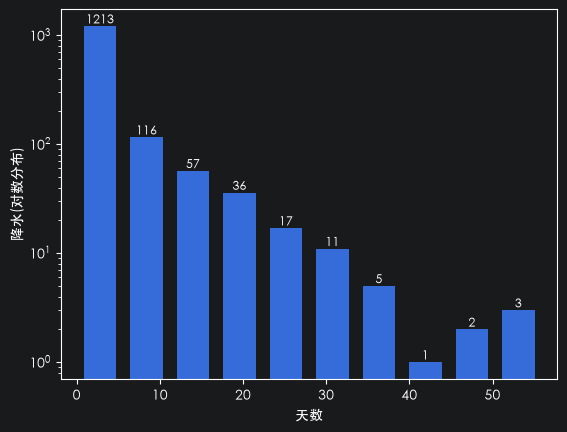

In [4]:
n, bins, patches = plt.hist(df['precipitation'], rwidth=0.7)
plt.yscale('log')
plt.ylabel('降水(对数分布)')
plt.xlabel('天数')

# 在每个柱顶添加数值
for i in range(len(n)):
    # n[i] 是频数，bins[i] 是左边界，bins[i+1] 是右边界
    x_pos = (bins[i] + bins[i+1]) / 2  # 柱子的中心位置
    y_pos = n[i]                       # 柱子的高度

    # 添加文本：高度值，水平居中，垂直底部对齐
    plt.text(x_pos, y_pos, f'{int(n[i])}',
             ha='center', va='bottom', fontsize=9)

plt.show()